# Sentiment Analysis on Customer Reviews

## Overview
This notebook analyzes customer reviews from the Olist dataset. We will:
1.  **Preprocess Text:** Clean and normalize the review text.
2.  **Sentiment Analysis:** Calculate sentiment scores (polarity) to classify reviews.
3.  **Topic Modeling:** Use LDA to identify common themes in negative reviews.

## Objectives
-   Understand customer sentiment distribution.
-   Identify key pain points from negative reviews.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from textblob import TextBlob

%matplotlib inline

In [2]:
# Connect to the SQLite database
db_path = '/home/yeqiu/dev/Portfolio/Project1 (DA)/olist.db'
conn = sqlite3.connect(db_path)

print(f"Connected to database at: {db_path}")

Connected to database at: /home/yeqiu/dev/Portfolio/Project1 (DA)/olist.db


## 1. Data Extraction
We need `review_comment_message` (the text) and `review_score` (the rating) from the `order_reviews` table.

In [3]:
query = """
SELECT 
    review_id,
    review_score,
    review_comment_title,
    review_comment_message
FROM order_reviews
WHERE review_comment_message IS NOT NULL
"""

df = pd.read_sql(query, conn)

print(f"Total Reviews with Comments: {len(df):,}")
display(df.head())

Total Reviews with Comments: 40,977


,review_id,review_score,review_comment_title,review_comment_message
0,e64fb393e7b32834bb789ff8bb30750e,5,None,Recebi bem antes do prazo estipulado.
1,f7c4243c7fe1938f181bec41a392bdeb,5,None,Parabéns lojas lannister adorei comprar pela I...
2,8670d52e15e00043ae7de4c01cc2fe06,4,recomendo,aparelho eficiente. no site a marca do aparelh...
3,4b49719c8a200003f700d3d986ea1a19,4,None,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
4,3948b09f7c818e2d86c9a546758b2335,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes..."


## 2. Text Preprocessing
We need to clean the text to make it suitable for analysis.
-   Convert to lowercase.
-   Remove punctuation and special characters.
-   Remove stop words (common words like "the", "is", "and" in Portuguese).

In [4]:
# Download Portuguese stop words
nltk.download('stopwords')
stop_words = set(nltk.corpus.stopwords.words('portuguese'))

def clean_text(text):
    if text is None:
        return ""
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zÀ-ÿ\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stop words
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Apply cleaning
df['cleaned_review'] = df['review_comment_message'].apply(clean_text)

display(df[['review_comment_message', 'cleaned_review']].head())

[nltk_data] Downloading package stopwords to /home/yeqiu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review_comment_message,cleaned_review
0,Recebi bem antes do prazo estipulado.,recebi bem antes prazo estipulado
1,Parabéns lojas lannister adorei comprar pela I...,parabéns lojas lannister adorei comprar intern...
2,aparelho eficiente. no site a marca do aparelh...,aparelho eficiente site marca aparelho impress...
3,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouco travandopelo valor ta boa
4,"Vendedor confiável, produto ok e entrega antes...",vendedor confiável produto ok entrega antes prazo


## 3. Sentiment Analysis
We will use the **Review Score** as the primary sentiment indicator.
-   **Positive:** 4-5 stars
-   **Neutral:** 3 stars
-   **Negative:** 1-2 stars

/tmp/ipykernel_1259321/462066074.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_category', data=df, order=['Negative', 'Neutral', 'Positive'], palette='coolwarm')


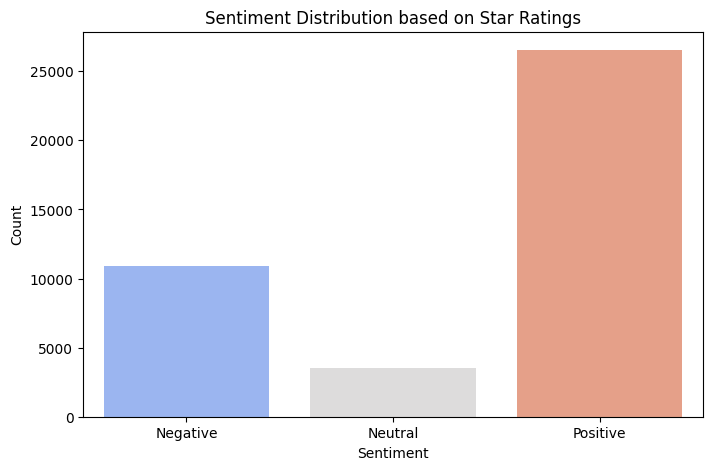

In [5]:
def classify_sentiment(score):
    if score >= 4:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment_category'] = df['review_score'].apply(classify_sentiment)

# Visualize Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment_category', data=df, order=['Negative', 'Neutral', 'Positive'], palette='coolwarm')
plt.title('Sentiment Distribution based on Star Ratings')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

## 4. Topic Modeling (LDA) on Negative Reviews
We want to understand *why* customers are unhappy. We will apply Latent Dirichlet Allocation (LDA) to the **Negative Reviews** to find common topics.

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Filter for negative reviews
negative_reviews = df[df['sentiment_category'] == 'Negative']['cleaned_review']

print(f"Number of Negative Reviews: {len(negative_reviews):,}")

# Vectorize text (create bag-of-words matrix)
# Ignore terms that appear in >90% of documents or <10 documents
vectorizer = CountVectorizer(max_df=0.9, min_df=10, stop_words=list(stop_words))
dtm = vectorizer.fit_transform(negative_reviews)

print(f"Document-Term Matrix Shape: {dtm.shape}")

Number of Negative Reviews: 10,890
Document-Term Matrix Shape: (10890, 1194)


In [7]:
# Train LDA Model
# Let's look for 3 main topics (e.g., Delivery, Product Quality, Customer Service)
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(dtm)

# Function to display top words per topic
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))
        print("\n")

print("Top words per topic:")
display_topics(lda, vectorizer.get_feature_names_out(), 10)

Top words per topic:
Topic 1:
produto recebi ainda entrega entregue prazo dia compra nao chegou


Topic 2:
produto veio qualidade diferente gostei chegou loja site defeito nao


Topic 3:
comprei recebi veio apenas produtos dois nota pedido duas entregue


